In [1]:
from util.text_util import join_texts
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType

Defining file path for saving dataset and loading it later on.

In [3]:
bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.BPMAI)

In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = BPMNDataset.get_names_key(use_types)
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = BPMNDataset.get_names_key(use_types)
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'


extract_names_from_models(bpmn_dataset, use_types=use_types, include_texts=False, include_documentation=False)


In [5]:
from mcp4cm.language_detection import filter_models_by_language
bpmn_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)

print(f"Filtered Dataset to {len(bpmn_dataset)} English models.")

Filtered Dataset to 9956 English models.


In [6]:

from bpmn.filter_functions import filter_empty_models, filter_models_by_min_element_count, \
    filter_models_by_max_element_count, filter_models_by_element_count, filter_models_by_empty_name_percentage, \
    filter_models_by_dummy_words, filter_models_by_median_name_length
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_min_element_count,
        filter_models_by_max_element_count,
        filter_models_by_element_count,
        filter_models_by_empty_name_percentage,
        #filter_models_by_dummy_words
        filter_models_by_median_name_length,
    ],
)

print(bpmn_dataset)

Dataset(name=BPMAI Dataset, models=9956)
Filtered out models where every element is unnamed: 3
Filtered out models with element counts smaller than 5: 22
Filtered out models with element counts greater than 200: 204
Filtered out models with element counts outside of 5 and 200: 0
Filtered out models with a empty name percentage higher than 0.35: 0
Filtered out models with a median name length smaller than 4: 5264
Dataset(name=BPMAI Dataset, models=4463)


In [7]:
file_path = 'data/bpmnmodelset/processed/bpmai/english_models.csv'
BPMNDataset.to_csv(bpmn_dataset, file_path)
print(f"Saved {len(bpmn_dataset)} models in dataset {bpmn_dataset.name} to csv file")


Saved 4463 models in dataset BPMAI Dataset to csv file



=== Dataset Statistics ===
Hash calculation and duplicate detection took 0.02 seconds.
Total number of models: 4463
Total unique files: 3868
Total duplicate files: 595
Number of duplicate groups: 266


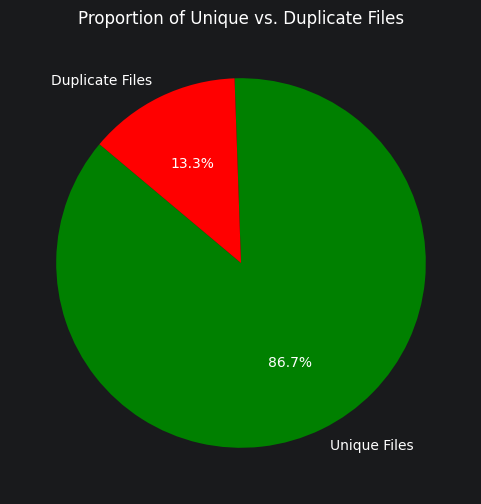

In [8]:
from mcp4cm.duplicate_detection import detect_duplicates_by_hash
hash_unique, hash_duplicate = detect_duplicates_by_hash(bpmn_dataset, key=key, inplace=False, plt_fig=True, print_results=True, keep_one=False)


In [9]:
print(f"Length of bpmn dataset = {len(hash_unique)}")
print(f"Length of duplicate_after_keeping_one = {len(hash_duplicate)}")


Length of bpmn dataset = 3868
Length of duplicate_after_keeping_one = 595


creating tfidf for names
Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 3679
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 4463
Total unique files: 3234
Total duplicate files: 1229
Number of duplicate groups: 445


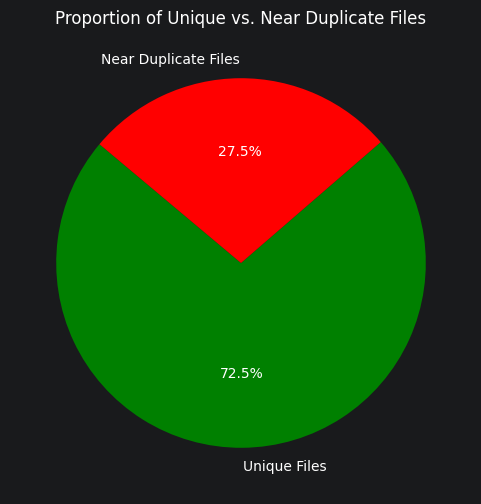

In [10]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector
unique_dataset, duplicate_dataset = tfidf_near_duplicate_detector(bpmn_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True, keep_one=False)

In [11]:
print(f"Length of bpmn dataset = {len(unique_dataset)}")
print(f"Length of bpmn dataset = {len(duplicate_dataset)}")


Length of bpmn dataset = 3234
Length of bpmn dataset = 1229


In [12]:
print(len(bpmn_dataset))

4463
